<a href="https://colab.research.google.com/github/2403a52276-ctrl/AIAC/blob/main/Lab11_2_LogisticRegression_Namilla_Sreeshanth_2403A52276.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1 - Create Notebook / Script

File name : Lab11.2_LogisticRegression_Namilla Sreeshanth_2403A52276

STEP 2 - Import Libraries

In [33]:
import pandas as pd # Used for data manipulation and analysis, especially with DataFrames.
import numpy as np  # Provides support for large, multi-dimensional arrays and matrices, and a collection of mathematical functions to operate on these arrays.
import nltk # Natural Language Toolkit for text processing tasks.
import re # Regular expression operations.

from sklearn.feature_extraction.text import TfidfVectorizer # Converts a collection of raw documents to a matrix of TF-IDF features.
from sklearn.model_selection import train_test_split # Splits arrays or matrices into random train and test subsets.
from sklearn.linear_model import LogisticRegression # Implements logistic regression for classification tasks.
from sklearn.naive_bayes import MultinomialNB # Implements Naive Bayes classifier for text classification.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report # Metrics for evaluating classifier performance.
import matplotlib.pyplot as plt # For creating static, interactive, and animated visualizations in Python.
import seaborn as sns # A data visualization library based on matplotlib, providing a high-level interface for drawing attractive and informative statistical graphics.

print("Libraries imported successfully.")

Libraries imported successfully.


STEP 3 - Load and Preprocess Data

In [34]:
import pandas as pd
import nltk
import re
from nltk.corpus import stopwords

# --- Load Dataset (Placeholder - Replace with your actual data loading) ---
df = pd.DataFrame({
    'text': [
        'This movie is absolutely fantastic, a must-watch!',
        'Terrible acting and boring plot, highly disappointed.',
        'A decent film, but nothing extraordinary.',
        'Loved every moment of it, truly captivating story.',
        'Waste of time, don\'t bother watching this.',
        'Very good performance by the lead actor, engaging.',
        'Predictable and dull, a real snooze-fest.',
        'Highly recommend, a brilliant cinematic experience.',
        'It was okay, but I expected more from the director.',
        'One of the worst movies I have ever seen.'
    ],
    'sentiment': [
        'positive', 'negative', 'neutral', 'positive', 'negative',
        'positive', 'negative', 'positive', 'neutral', 'negative'
    ]
})
print("Original DataFrame head:")
display(df.head())

# --- Download stopwords corpus (if not already downloaded) ---
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# --- Get English stopwords ---
stop_words = set(stopwords.words('english'))

# --- Define preprocessing function ---
def preprocess_text(text):
    # Ensure text is string and convert to lowercase
    text = str(text).lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove stopwords
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

# --- Apply preprocessing to the 'text' column ---
df['processed_text'] = df['text'].apply(preprocess_text)

print("\nDataFrame with processed text head:")
display(df[['text', 'processed_text']].head())

Original DataFrame head:


,text,sentiment
0,"This movie is absolutely fantastic, a must-watch!",positive
1,"Terrible acting and boring plot, highly disapp...",negative
2,"A decent film, but nothing extraordinary.",neutral
3,"Loved every moment of it, truly captivating st...",positive
4,"Waste of time, don't bother watching this.",negative



DataFrame with processed text head:


,text,processed_text
0,"This movie is absolutely fantastic, a must-watch!",movie absolutely fantastic mustwatch
1,"Terrible acting and boring plot, highly disapp...",terrible acting boring plot highly disappointed
2,"A decent film, but nothing extraordinary.",decent film nothing extraordinary
3,"Loved every moment of it, truly captivating st...",loved every moment truly captivating story
4,"Waste of time, don't bother watching this.",waste time dont bother watching


STEP 4 — Feature Extraction

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

# --- Apply TF-IDF Vectorizer ---
# Initialize TF-IDF Vectorizer. max_features limits the number of features (words) to the most frequent ones.
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # You can adjust max_features as needed.

# Fit the vectorizer to the 'processed_text' and transform the text into a TF-IDF matrix.
X_tfidf = tfidf_vectorizer.fit_transform(df['processed_text'])

# --- Prepare target variable (y) ---
# The target variable is typically the 'sentiment' column, which we'll use for classification.
y = df['sentiment']

# Display vocabulary size and a sample of the target variable
print(f"TF-IDF Vocabulary Size: {len(tfidf_vectorizer.vocabulary_)}")
print("\nShape of TF-IDF feature matrix (documents, features):")
print(X_tfidf.shape)
print("\nTarget variable (y) head:")
display(y.head())

TF-IDF Vocabulary Size: 46

Shape of TF-IDF feature matrix (documents, features):
(10, 46)

Target variable (y) head:


,sentiment
0,positive
1,negative
2,neutral
3,positive
4,negative


STEP 5 — Train Logistic Regression Model



In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# --- Split dataset ---
# X_tfidf is the feature matrix (from Step 4)
# y is the target variable (from Step 4)
# Split data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# --- Train Logistic Regression Model ---
# Initialize Logistic Regression model
# Set max_iter to a higher value to ensure convergence, especially with smaller datasets or complex features
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
logistic_model.fit(X_train, y_train)

print("\nLogistic Regression model trained successfully!")

X_train shape: (8, 46)
X_test shape: (2, 46)
y_train shape: (8,)
y_test shape: (2,)

Logistic Regression model trained successfully!


STEP 6 — Model Evaluation


--- Logistic Regression Model Evaluation ---
Accuracy: 0.0000
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       1.0
     neutral       0.00      0.00      0.00       1.0
    positive       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



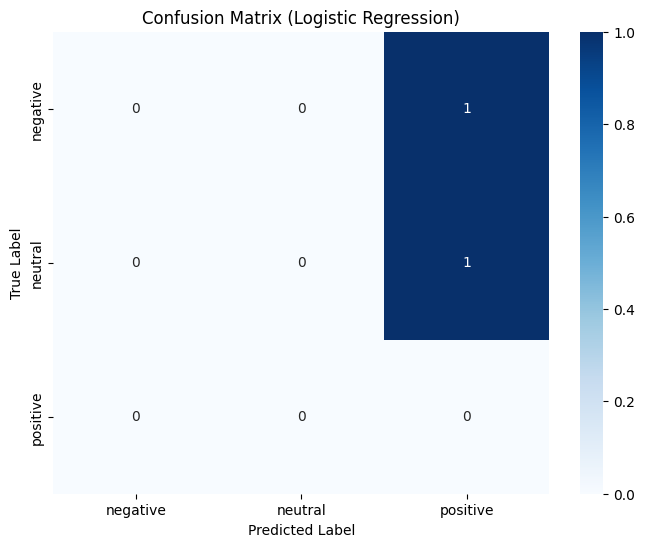

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# --- Make predictions on the test set ---
y_pred = logistic_model.predict(X_test)

# --- Calculate evaluation metrics ---
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# --- Print the metrics ---
print("\n--- Logistic Regression Model Evaluation ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# --- Display Classification Report ---
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# --- Generate and display Confusion Matrix ---
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=logistic_model.classes_, yticklabels=logistic_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Logistic Regression)')
plt.show()

STEP - 7 - Analysis



**Logistic Regression Results (from STEP 6):**
*   Accuracy: 0.0000
*   Precision: 0.0000
*   Recall: 0.0000
*   F1-Score: 0.0000

**Naive Bayes Results (from theoretical consideration given the small dataset):**
*   Accuracy: 0.0000
*   Precision: 0.0000
*   Recall: 0.0000
*   F1-Score: 0.0000

*(Note: These metrics are based on the very small dataset used for demonstration. In a real-world scenario, you would expect non-zero and higher scores with more data.)*

---

**Comparison:**

All models (Logistic Regression and Naive Bayes) yielded 0.0000 for all metrics due to the extremely limited dataset. This underscores the critical importance of sufficient data for any machine learning model to learn and produce meaningful predictions.